# Health Insurance Claims & Fraud Signals Analysis

**Perspective:** a commercial health plan's claims analytics team, reviewing two years of claims
(Jan 2024 – Dec 2025, data as of 2025-12-31) across three lenses:

| Lens | Questions | Queries |
|---|---|---|
| **Payer efficiency** | Where do denials come from? How fast do we adjudicate? | 01, 02, 03, 05, 06 |
| **Cost containment** | Which conditions and members drive spend? What is the cost trend? | 04, 07, 08, 12 |
| **Claims integrity** | Are duplicates, billing outliers, or provider patterns leaking dollars? | 09, 10, 11 |

Each section loads a query from `../sql/`, runs it against `../data/claims.db`, shows the result, and charts it.
Charts are also saved to `../images/` and results to `../data/results/` (used by the README and slide deck).

> All data is synthetic, generated by `scripts/generate_data.py`.

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

ROOT = Path.cwd() if (Path.cwd() / "data" / "claims.db").exists() else Path.cwd().parent
SQL_DIR, IMG_DIR, RES_DIR = ROOT / "sql", ROOT / "images", ROOT / "data" / "results"
IMG_DIR.mkdir(exist_ok=True); RES_DIR.mkdir(exist_ok=True)
con = sqlite3.connect(ROOT / "data" / "claims.db")

# Palette: navy ink + teal primary; coral reserved for risk/flags. Validated for CVD separation.
NAVY, TEAL, CORAL, BLUE, GOLD = "#0B1F3A", "#0F9D8F", "#E0694F", "#3B6FB6", "#B8892A"
MUTED, GRID = "#6B7280", "#E5E7EB"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "figure.facecolor": "white",
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "axes.titleweight": "bold",
    "axes.titlesize": 13, "axes.titlecolor": NAVY, "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "xtick.color": MUTED, "ytick.color": MUTED,
    "font.size": 10, "legend.frameon": False,
})
pd.set_option("display.max_columns", 30); pd.set_option("display.width", 200)


def run_sql(name: str) -> pd.DataFrame:
    """Run sql/<name>.sql, save the result to data/results/<name>.csv and return it."""
    df = pd.read_sql((SQL_DIR / f"{name}.sql").read_text(), con)
    df.to_csv(RES_DIR / f"{name}.csv", index=False)
    return df


def save(fig, name):
    fig.tight_layout()
    fig.savefig(IMG_DIR / f"{name}.png", bbox_inches="tight")
    plt.show()


def _money(x, _=None):
    if abs(x) >= 1e6:
        return f"${x/1e6:.1f}M"
    if abs(x) >= 1e3:
        return f"${x/1e3:.1f}K".replace(".0K", "K")
    return f"${x:,.0f}"


money = mtick.FuncFormatter(_money)

## 0. Dataset overview

In [2]:
tables = ["members", "policies", "providers", "claims", "diagnosis_codes", "procedure_codes", "rejection_reasons"]
overview = pd.DataFrame({"table": tables,
                         "rows": [con.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0] for t in tables]})
display(overview)

kpi = pd.read_sql("""
    SELECT COUNT(*)                                             AS claims,
           ROUND(SUM(billed_amount))                            AS billed,
           ROUND(SUM(COALESCE(approved_amount, 0)))             AS approved,
           ROUND(100.0 * AVG(claim_status = 'Approved'), 1)     AS approved_pct,
           ROUND(100.0 * AVG(claim_status = 'Rejected'), 1)     AS rejected_pct,
           ROUND(100.0 * AVG(claim_status = 'Pending'), 1)      AS pending_pct,
           MIN(service_date) AS first_service, MAX(service_date) AS last_service
    FROM claims""", con)
kpi.to_csv(RES_DIR / "00_kpis.csv", index=False)
kpi

,table,rows
0,members,10000
1,policies,19854
2,providers,1200
3,claims,199195
4,diagnosis_codes,26
5,procedure_codes,35
6,rejection_reasons,10


,claims,billed,approved,approved_pct,rejected_pct,pending_pct,first_service,last_service
0,199195,116375694.0,50781610.0,84.1,13.8,2.2,2024-01-01,2025-12-20


![schema](../images/schema_diagram.png)

---
# Part 1 — Payer efficiency

## Q01. Rejection rate by provider vs. specialty benchmark
Providers with ≥150 adjudicated claims, ranked by how far their rejection rate sits above their specialty's pooled rate.

In [3]:
q01 = run_sql("01_rejection_rate_by_provider")
q01.head(15)

,provider_id,provider_name,specialty,network_status,adjudicated_claims,rejected_claims,rejection_rate_pct,specialty_rate_pct,pts_above_specialty,rank_in_specialty,rejected_billed
0,PR20798,Crescent Family Medicine Associates,Family Medicine,Out-of-Network,275,159,57.82,15.12,42.70,1,101295.0
1,PR20596,Cedar Diagnostics Lab,Laboratory,Out-of-Network,850,429,50.47,12.95,37.52,1,17675.0
2,PR20582,Parkside Physical Therapy,Physical Therapy,Out-of-Network,186,103,55.38,18.66,36.72,1,22866.0
3,PR20575,Horizon Diagnostics Lab,Laboratory,Out-of-Network,535,256,47.85,12.95,34.90,2,10414.0
4,PR20705,Dr. Hassan Williams,Behavioral Health,Out-of-Network,225,106,47.11,12.73,34.38,1,20157.0
5,PR20677,Bayside Behavioral Health Associates,Behavioral Health,Out-of-Network,290,134,46.21,12.73,33.48,2,40023.0
6,PR20289,Dr. Lisa Ali,Gastroenterology,Out-of-Network,664,281,42.32,10.98,31.34,1,145918.0
7,PR20137,Pinecrest Cardiology Associates,Cardiology,Out-of-Network,193,90,46.63,16.12,30.51,1,62556.0
8,PR20903,Valley Internal Medicine Associates,Internal Medicine,Out-of-Network,557,268,48.11,17.75,30.36,1,232527.0
9,PR20302,Crescent Neurology Associates,Neurology,Out-of-Network,432,182,42.13,11.99,30.14,1,46108.0


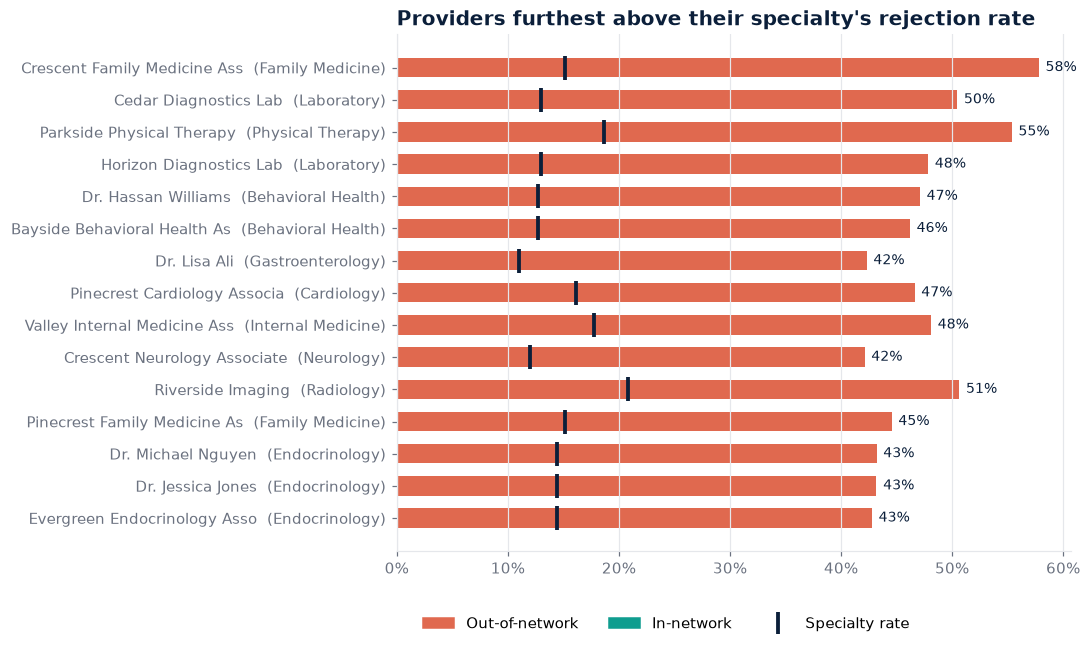

In [4]:
top = q01.head(15).iloc[::-1]
labels = top.provider_name.str.slice(0, 28) + "  (" + top.specialty + ")"
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(labels, top.rejection_rate_pct, color=[CORAL if n == "Out-of-Network" else TEAL for n in top.network_status], height=0.6)
ax.scatter(top.specialty_rate_pct, labels, color=NAVY, marker="|", s=260, linewidths=2.5, zorder=3, label="Specialty rate")
for y, v in enumerate(top.rejection_rate_pct):
    ax.text(v + 0.6, y, f"{v:.0f}%", va="center", color=NAVY, fontsize=9)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(axis="y", visible=False)
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
ax.legend(handles=[Patch(color=CORAL, label="Out-of-network"), Patch(color=TEAL, label="In-network"),
                   Line2D([0], [0], color=NAVY, marker="|", ls="", ms=14, mew=2.5, label="Specialty rate")],
          loc="upper center", bbox_to_anchor=(0.4, -0.1), ncol=3)
ax.set_title("Providers furthest above their specialty's rejection rate")
save(fig, "q01_rejection_by_provider")

**Read:** the worst outliers are overwhelmingly **out-of-network** providers billing HMO/EPO members, where the plan has no OON benefit.
That is a *member steering / network adequacy* problem more than a provider-behaviour problem — the fix is referral management
and directory accuracy, not provider education.

## Q02. Rejection reasons — volume, dollars, and avoidability

In [5]:
q02 = run_sql("02_rejection_reasons")
q02

,reason_code,description,category,avoidability,rejected_claims,pct_of_rejections,cumulative_pct,rejected_billed,avg_billed_per_denial
0,R05,"Out-of-network provider, no OON benefit",Network,Avoidable,7953,29.01,29.0,4726112.0,594.0
1,R06,Diagnosis/procedure code mismatch or invalid code,Coding,Avoidable,5957,21.73,50.7,3747440.0,629.0
2,R07,Missing or incomplete claim information,Administrative,Avoidable,4894,17.85,68.6,2457842.0,502.0
3,R01,Duplicate claim submission,Payment Integrity,Avoidable,2909,10.61,79.2,2089464.0,718.0
4,R03,Service not covered under member's plan,Benefits,Clinical/Policy,1838,6.71,85.9,755104.0,411.0
5,R08,Timely filing limit exceeded,Administrative,Avoidable,1435,5.23,91.1,927908.0,647.0
6,R02,Missing or invalid prior authorization,Utilization Management,Avoidable,848,3.09,94.2,3079410.0,3631.0
7,R09,Not medically necessary,Clinical Review,Clinical/Policy,693,2.53,96.8,707551.0,1021.0
8,R04,Member not eligible on date of service,Eligibility,Avoidable,515,1.88,98.7,245305.0,476.0
9,R10,Billed amount exceeds reasonable & customary r...,Payment Integrity,Clinical/Policy,370,1.35,100.0,2825666.0,7637.0


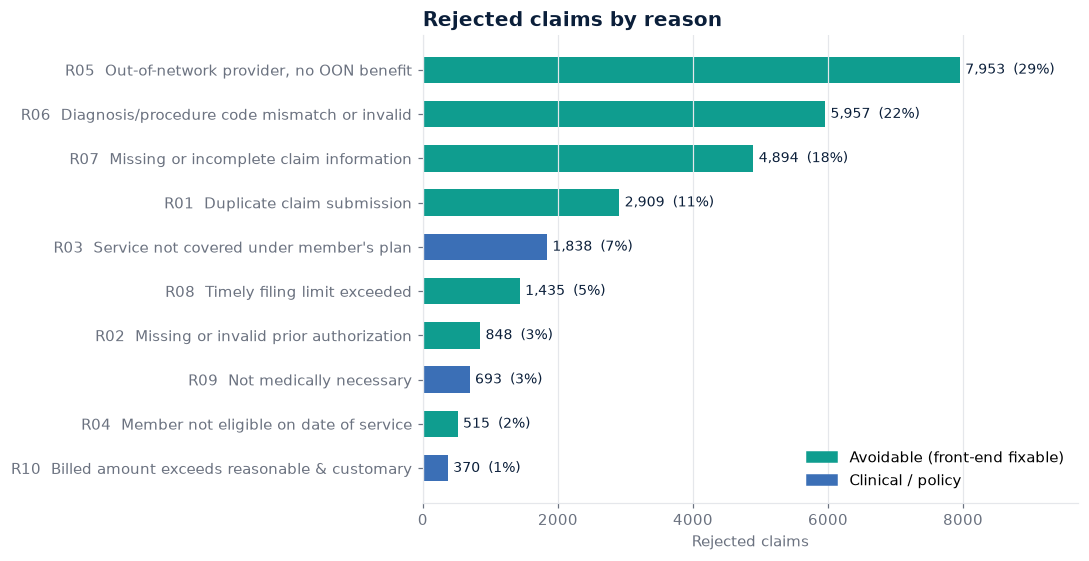

Avoidable share of denials: 89.4%


In [6]:
d = q02.iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 5.2))
ax.barh(d.reason_code + "  " + d.description.str.slice(0, 44), d.rejected_claims,
        color=[TEAL if a == "Avoidable" else BLUE for a in d.avoidability], height=0.6)
for y, (n, pct) in enumerate(zip(d.rejected_claims, d.pct_of_rejections)):
    ax.text(n + 80, y, f"{n:,}  ({pct:.0f}%)", va="center", fontsize=9, color=NAVY)
ax.grid(axis="y", visible=False)
ax.legend(handles=[Patch(color=TEAL, label="Avoidable (front-end fixable)"), Patch(color=BLUE, label="Clinical / policy")], loc="lower right")
ax.set_title("Rejected claims by reason")
ax.set_xlabel("Rejected claims")
ax.set_xlim(0, d.rejected_claims.max() * 1.22)
save(fig, "q02_rejection_reasons")
avoid = q02.loc[q02.avoidability == "Avoidable", "rejected_claims"].sum() / q02.rejected_claims.sum()
print(f"Avoidable share of denials: {avoid:.1%}")

## Q03. Rejection mix by specialty
Conditional aggregation pivots the reason mix per specialty; `ROW_NUMBER()` picks each specialty's top denial driver.

In [7]:
q03 = run_sql("03_rejection_reason_by_specialty")
q03

,specialty,adjudicated,rejection_rate_pct,prior_auth_pct,out_of_network_pct,coding_pct,duplicate_pct,admin_eligibility_pct,clinical_policy_pct,top_rejection_reason
0,General Surgery,1636,21.94,35.38,24.79,12.53,6.41,16.71,4.18,R02 - Missing or invalid prior authorization
1,Radiology,14487,20.01,18.25,25.18,15.80,11.42,16.38,12.97,"R05 - Out-of-network provider, no OON benefit"
2,Physical Therapy,6644,19.73,0.00,47.14,13.35,7.17,17.32,15.03,"R05 - Out-of-network provider, no OON benefit"
3,Oncology,1043,17.26,30.56,5.56,18.33,8.33,22.78,14.44,R02 - Missing or invalid prior authorization
4,Internal Medicine,20474,15.08,0.00,38.37,20.40,11.01,22.31,7.90,"R05 - Out-of-network provider, no OON benefit"
5,Family Medicine,20587,14.84,0.00,36.73,20.82,10.97,23.57,7.92,"R05 - Out-of-network provider, no OON benefit"
6,Cardiology,8624,14.63,9.67,17.51,24.01,12.68,23.38,12.76,R06 - Diagnosis/procedure code mismatch or inv...
7,Orthopedics,6859,14.56,1.50,29.23,26.93,9.81,22.52,10.01,"R05 - Out-of-network provider, no OON benefit"
8,Endocrinology,12414,14.40,0.00,34.14,24.85,11.08,21.88,8.06,"R05 - Out-of-network provider, no OON benefit"
9,Urgent Care,11265,13.76,0.00,38.26,19.61,7.81,26.84,7.48,"R05 - Out-of-network provider, no OON benefit"


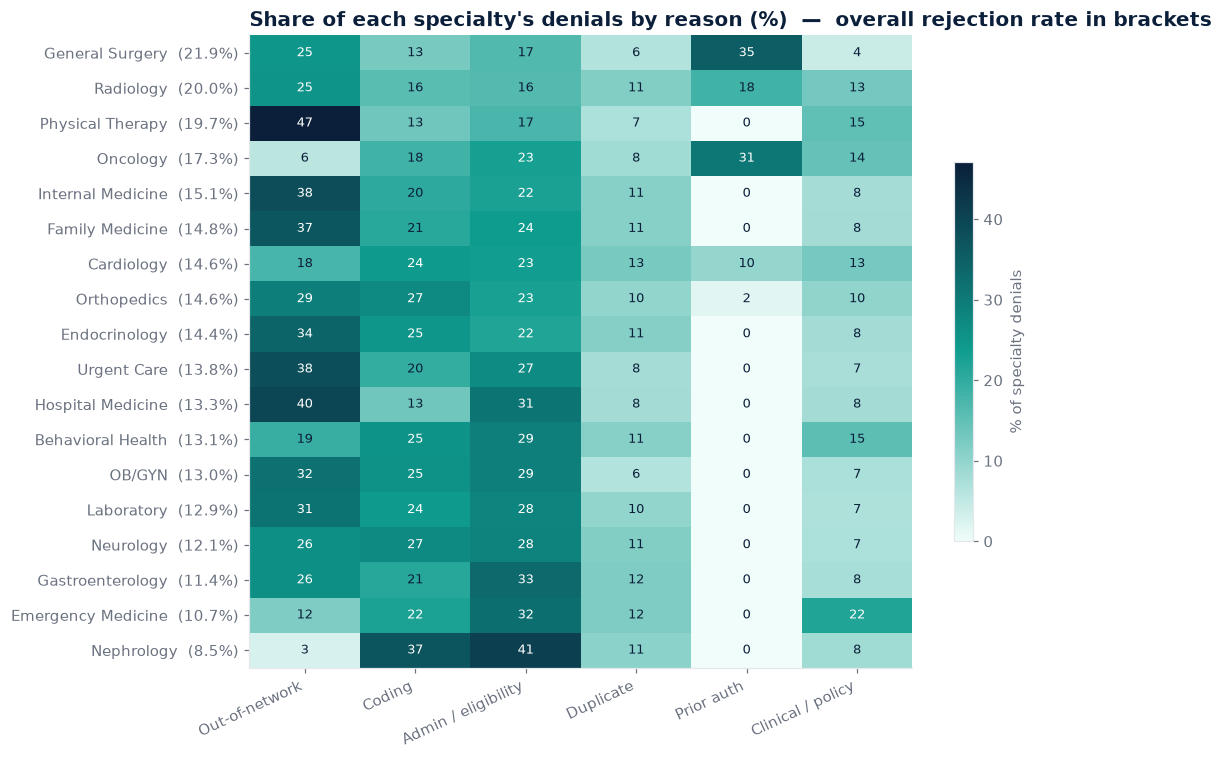

In [8]:
cols = ["out_of_network_pct", "coding_pct", "admin_eligibility_pct", "duplicate_pct", "prior_auth_pct", "clinical_policy_pct"]
nice = ["Out-of-network", "Coding", "Admin / eligibility", "Duplicate", "Prior auth", "Clinical / policy"]
h = q03.set_index("specialty")[cols]
fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(h.values, cmap=plt.cm.colors.LinearSegmentedColormap.from_list("teal", ["#F0FDFA", TEAL, NAVY]), aspect="auto")
ax.set_xticks(range(len(nice)), nice, rotation=25, ha="right")
ax.set_yticks(range(len(h)), [f"{s}  ({r:.1f}%)" for s, r in zip(h.index, q03.rejection_rate_pct)])
for i in range(h.shape[0]):
    for j in range(h.shape[1]):
        v = h.values[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8.5, color="white" if v > h.values.max() * 0.45 else NAVY)
ax.grid(False)
ax.set_title("Share of each specialty's denials by reason (%)  —  overall rejection rate in brackets")
fig.colorbar(im, ax=ax, shrink=0.6, label="% of specialty denials")
save(fig, "q03_reason_by_specialty")

## Q05. Adjudication turnaround time
`julianday()` date math plus window-based median / P90. The **manual-review path** (prior-auth procedures or billed > $2,500) is where the time goes.

In [9]:
q05 = run_sql("05_approval_turnaround")
q05

,claim_type,review_path,claim_status,claims,avg_days,median_days,p90_days,pct_within_15d,pct_within_30d
0,Institutional,Auto-adjudication path,Approved,16649,3.7,3.0,8.0,99.3,100.0
1,Institutional,Auto-adjudication path,Rejected,1996,5.7,3.0,15.0,90.2,95.9
2,Institutional,Manual review path,Approved,5265,16.6,15.0,30.0,53.8,90.6
3,Institutional,Manual review path,Rejected,1212,13.6,12.0,29.0,62.5,91.5
4,Professional,Auto-adjudication path,Approved,140330,3.7,3.0,8.0,99.3,100.0
5,Professional,Auto-adjudication path,Rejected,22249,3.4,2.0,7.0,98.4,99.6
6,Professional,Manual review path,Approved,5256,16.6,15.0,29.0,53.4,91.2
7,Professional,Manual review path,Rejected,1955,15.3,14.0,32.0,57.0,88.3


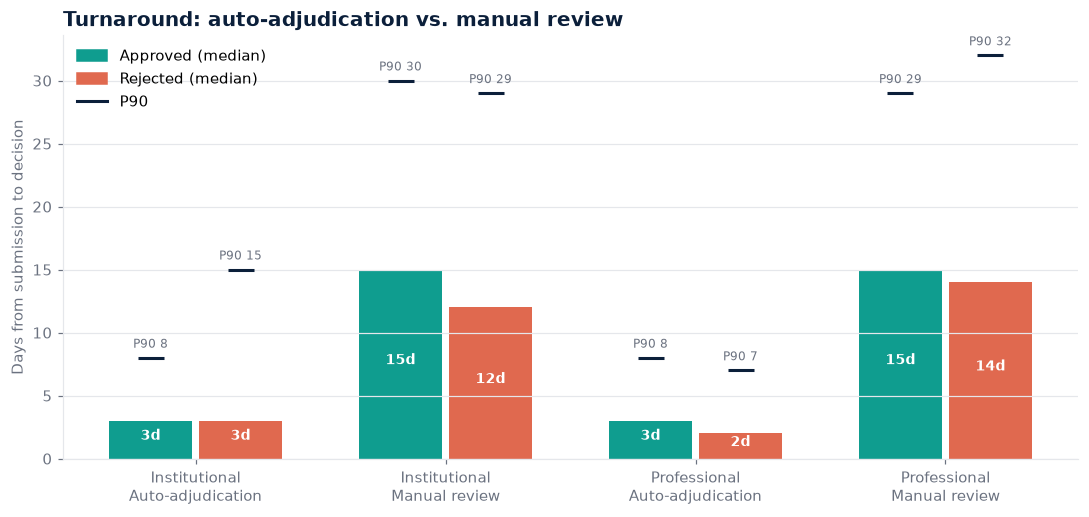

In [10]:
g = q05.assign(label=q05.claim_type + "\n" + q05.review_path.str.replace(" path", ""))
piv = g.pivot_table(index="label", columns="claim_status", values="median_days")
p90 = g.pivot_table(index="label", columns="claim_status", values="p90_days")
fig, ax = plt.subplots(figsize=(10, 4.8))
x = range(len(piv)); w = 0.36
for k, (status, color) in enumerate([("Approved", TEAL), ("Rejected", CORAL)]):
    xs = [i + (k - 0.5) * w for i in x]
    ax.bar(xs, piv[status], width=w * 0.92, color=color, label=f"{status} — median")
    ax.scatter(xs, p90[status], color=NAVY, marker="_", s=300, linewidths=2, zorder=3)
    for xi, m, p in zip(xs, piv[status], p90[status]):
        ax.text(xi, p + 0.8, f"P90 {p:.0f}", ha="center", fontsize=8, color=MUTED)
        ax.text(xi, m / 2, f"{m:.0f}d", ha="center", color="white", fontsize=9, fontweight="bold")
ax.set_xticks(list(x), piv.index)
ax.set_ylabel("Days from submission to decision")
ax.grid(axis="x", visible=False)
ax.legend(handles=[Patch(color=TEAL, label="Approved (median)"), Patch(color=CORAL, label="Rejected (median)"),
                   Line2D([0], [0], color=NAVY, lw=2, label="P90")], loc="upper left")
ax.set_title("Turnaround: auto-adjudication vs. manual review")
save(fig, "q05_turnaround")

## Q06. Monthly turnaround trend & SLA compliance
`LAG()` gives month-over-month change; a 3-month rolling average smooths noise. The 2025 auto-adjudication rollout shows up clearly.

In [11]:
q06 = run_sql("06_turnaround_trend_and_backlog")
q06

,month,decided_claims,avg_turnaround_days,mom_change_days,rolling_3m_days,pct_within_15d,pct_within_30d
0,2024-01,5808,4.91,NaN,4.91,95.2,99.2
1,2024-02,8433,4.85,-0.06,4.88,95.7,99.1
2,2024-03,8792,4.82,-0.03,4.86,95.6,99.1
3,2024-04,7618,4.90,0.08,4.86,95.4,98.9
4,2024-05,7618,4.97,0.06,4.90,95.2,99.0
5,2024-06,7580,4.95,-0.02,4.94,95.0,99.0
6,2024-07,7297,5.07,0.12,4.99,94.8,98.9
7,2024-08,7452,4.90,-0.17,4.97,95.4,99.1
8,2024-09,7923,4.84,-0.06,4.94,95.4,99.0
9,2024-10,8695,4.80,-0.04,4.85,95.9,99.2


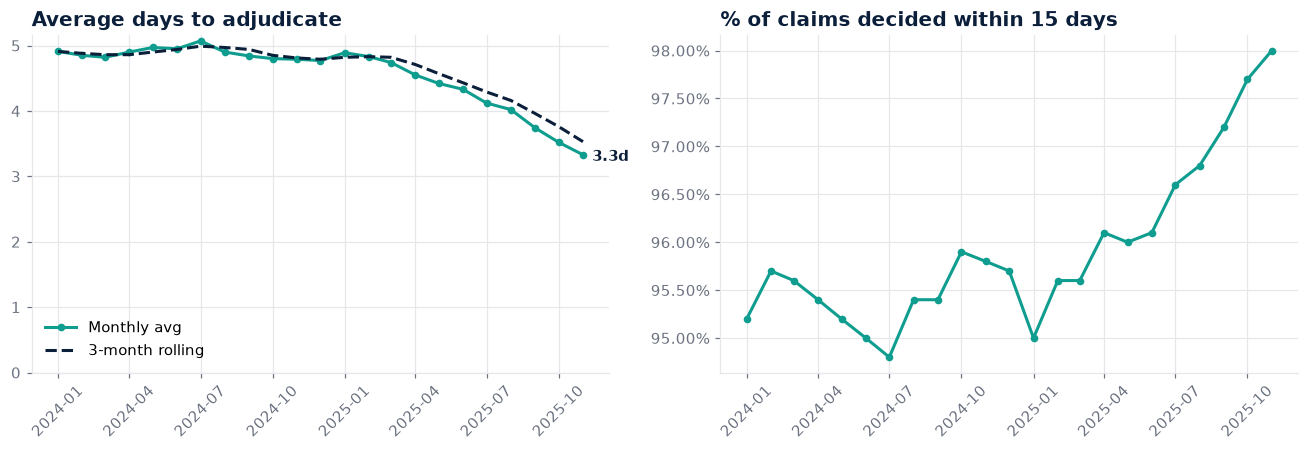

,age_bucket,pending_claims,pending_billed
0,0-15 days,3067,1909325.0
1,16-30 days,1088,1204623.0
2,31-60 days,49,48524.0
3,60+ days,79,194522.0


In [12]:
m = pd.to_datetime(q06.month)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.2))
a1.plot(m, q06.avg_turnaround_days, color=TEAL, lw=2, marker="o", ms=4, label="Monthly avg")
a1.plot(m, q06.rolling_3m_days, color=NAVY, lw=2, ls="--", label="3-month rolling")
a1.set_title("Average days to adjudicate"); a1.set_ylim(0, None); a1.legend(loc="lower left")
a1.annotate(f"{q06.avg_turnaround_days.iloc[-1]:.1f}d", (m.iloc[-1], q06.avg_turnaround_days.iloc[-1]),
            xytext=(6, -4), textcoords="offset points", color=NAVY, fontweight="bold")
a2.plot(m, q06.pct_within_15d, color=TEAL, lw=2, marker="o", ms=4)
a2.yaxis.set_major_formatter(mtick.PercentFormatter()); a2.set_title("% of claims decided within 15 days")
for a in (a1, a2):
    a.tick_params(axis="x", rotation=45)
save(fig, "q06_turnaround_trend")
backlog = pd.read_sql("""
    SELECT CASE WHEN age <= 15 THEN '0-15 days' WHEN age <= 30 THEN '16-30 days'
                WHEN age <= 60 THEN '31-60 days' ELSE '60+ days' END AS age_bucket,
           COUNT(*) AS pending_claims, ROUND(SUM(billed_amount)) AS pending_billed
    FROM (SELECT billed_amount, julianday('2025-12-31') - julianday(submission_date) AS age
          FROM claims WHERE claim_status = 'Pending')
    GROUP BY 1 ORDER BY MIN(age)""", con)
backlog

---
# Part 2 — Cost containment

## Q04. Average claim cost by diagnosis
A true median in SQLite via `ROW_NUMBER()` + `COUNT()` windows. Mean ≫ median flags diagnoses whose cost is driven by a few expensive episodes (surgery, admissions).

In [13]:
q04 = run_sql("04_avg_cost_by_diagnosis")
q04

,diagnosis_code,description,category,approved_claims,members,avg_billed,avg_approved,median_approved,approved_to_billed_pct,total_approved,approved_per_member
0,O80,Encounter for full-term uncomplicated delivery,Maternity,931,734,4597.0,2643.0,3183.0,57.5,2460693.0,3352.0
1,K80.20,Calculus of gallbladder without obstruction,Digestive,5640,3137,2670.0,1579.0,472.0,59.1,8904596.0,2839.0
2,C50.911,Malignant neoplasm of right female breast,Oncology,652,108,2368.0,1288.0,790.0,54.4,839802.0,7776.0
3,S82.201A,"Fracture of shaft of right tibia, initial enco...",Injury,6450,3596,2161.0,1211.0,491.0,56.0,7809040.0,2172.0
4,M17.11,"Primary osteoarthritis, right knee",Musculoskeletal,4144,635,1908.0,1031.0,151.0,54.0,4273073.0,6729.0
5,I25.10,Atherosclerotic heart disease of native corona...,Circulatory,4047,593,1678.0,854.0,167.0,50.9,3454966.0,5826.0
6,S06.0X0A,Concussion without loss of consciousness,Injury,6501,3622,858.0,486.0,453.0,56.7,3161357.0,873.0
7,C34.90,Malignant neoplasm of bronchus or lung,Oncology,412,66,835.0,481.0,489.0,57.6,198292.0,3004.0
8,R07.9,"Chest pain, unspecified",Symptoms & Signs,6335,3450,528.0,311.0,413.0,59.0,1971757.0,572.0
9,K21.9,Gastro-esophageal reflux disease,Digestive,6400,3510,534.0,302.0,128.0,56.5,1931987.0,550.0


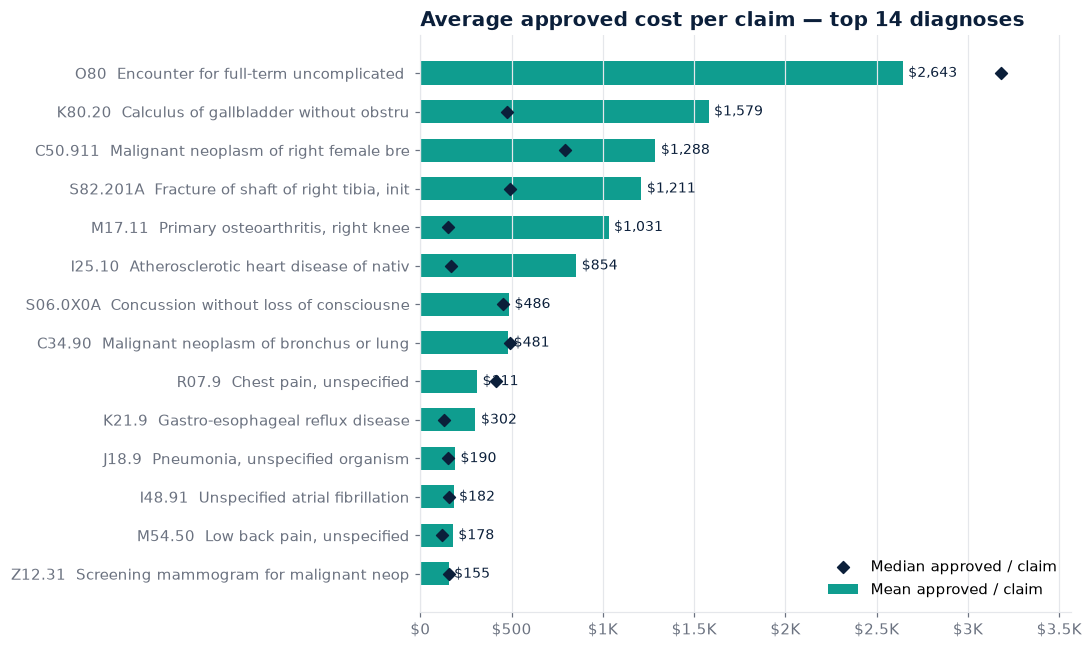

In [14]:
d = q04.head(14).iloc[::-1]
lab = d.diagnosis_code + "  " + d.description.str.slice(0, 38)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(lab, d.avg_approved, color=TEAL, height=0.6, label="Mean approved / claim")
ax.scatter(d.median_approved, lab, color=NAVY, marker="D", s=30, zorder=3, label="Median approved / claim")
for y, v in enumerate(d.avg_approved):
    ax.text(v + 30, y, f"${v:,.0f}", va="center", fontsize=9, color=NAVY)
ax.xaxis.set_major_formatter(money); ax.grid(axis="y", visible=False)
ax.set_xlim(0, max(d.avg_approved.max(), d.median_approved.max()) * 1.12)
ax.legend(loc="lower right"); ax.set_title("Average approved cost per claim — top 14 diagnoses")
save(fig, "q04_cost_by_diagnosis")

## Q07. High-cost members (top 1%)
`NTILE(100)` isolates the top percentile; `GROUP_CONCAT` summarises each member's chronic-condition categories.

In [15]:
q07 = run_sql("07_high_cost_members")
q07.head(15)

,member_id,age,gender,state,plan_type,metal_tier,approved_claims,distinct_providers,approved_spend,pct_of_total_spend,chronic_dx_count,chronic_categories
0,M105380,65,M,FL,EPO,Silver,536,92,263557.0,0.519,4,"Circulatory,Musculoskeletal,Endocrine"
1,M104921,52,M,NY,HDHP,Bronze,227,39,129833.0,0.256,4,"Renal,Circulatory,Behavioral Health"
2,M104326,64,F,CA,PPO,Silver,267,59,126652.0,0.249,7,"Musculoskeletal,Circulatory,Behavioral Health,..."
3,M102548,62,M,CA,PPO,Silver,291,48,125257.0,0.247,4,"Circulatory,Respiratory,Musculoskeletal"
4,M107382,65,M,GA,HDHP,Bronze,176,39,109116.0,0.215,4,"Musculoskeletal,Endocrine,Respiratory,Circulatory"
5,M101469,65,M,CA,PPO,Silver,146,30,108984.0,0.215,4,"Circulatory,Endocrine,Musculoskeletal"
6,M105001,64,M,FL,PPO,Gold,261,46,106832.0,0.210,3,"Endocrine,Circulatory"
7,M106448,65,M,NY,HDHP,Bronze,176,45,103907.0,0.205,5,"Circulatory,Endocrine,Musculoskeletal,Respiratory"
8,M103509,61,F,IL,PPO,Bronze,238,48,100550.0,0.198,0,NaN
9,M107603,57,F,GA,PPO,Silver,223,43,97278.0,0.192,4,"Circulatory,Respiratory,Endocrine"


Top-1% members listed: 50  |  median age 62  |  median chronic dx 5  |  avg spend $83,127


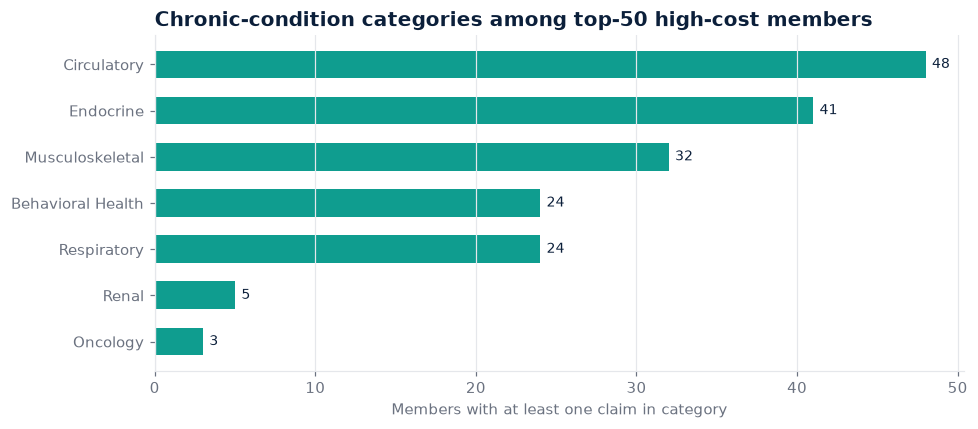

In [16]:
print(f"Top-1% members listed: {len(q07)}  |  median age {q07.age.median():.0f}  |  "
      f"median chronic dx {q07.chronic_dx_count.median():.0f}  |  avg spend ${q07.approved_spend.mean():,.0f}")
cats = q07.chronic_categories.dropna().str.split(",").explode().value_counts()
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(cats.index[::-1], cats.values[::-1], color=TEAL, height=0.6)
for y, v in enumerate(cats.values[::-1]):
    ax.text(v + 0.4, y, f"{v}", va="center", fontsize=9, color=NAVY)
ax.grid(axis="y", visible=False)
ax.set_title(f"Chronic-condition categories among top-{len(q07)} high-cost members")
ax.set_xlabel("Members with at least one claim in category")
save(fig, "q07_high_cost_conditions")

## Q08. Cost concentration (Pareto by member decile)

In [17]:
q08 = run_sql("08_cost_concentration")
q08

,decile,members,min_member_spend,max_member_spend,avg_member_spend,pct_of_spend,cumulative_pct_of_spend
0,1,940,13795.0,263557.0,27861.0,51.6,51.6
1,2,940,7647.0,13786.0,10204.0,18.9,70.5
2,3,939,4973.0,7638.0,6259.0,11.6,82.0
3,4,939,2814.0,4970.0,3782.0,7.0,89.0
4,5,939,1792.0,2813.0,2260.0,4.2,93.2
5,6,939,1233.0,1791.0,1491.0,2.8,96.0
6,7,939,824.0,1232.0,1020.0,1.9,97.9
7,8,939,509.0,824.0,664.0,1.2,99.1
8,9,939,231.0,509.0,375.0,0.7,99.8
9,10,939,7.0,230.0,124.0,0.2,100.0


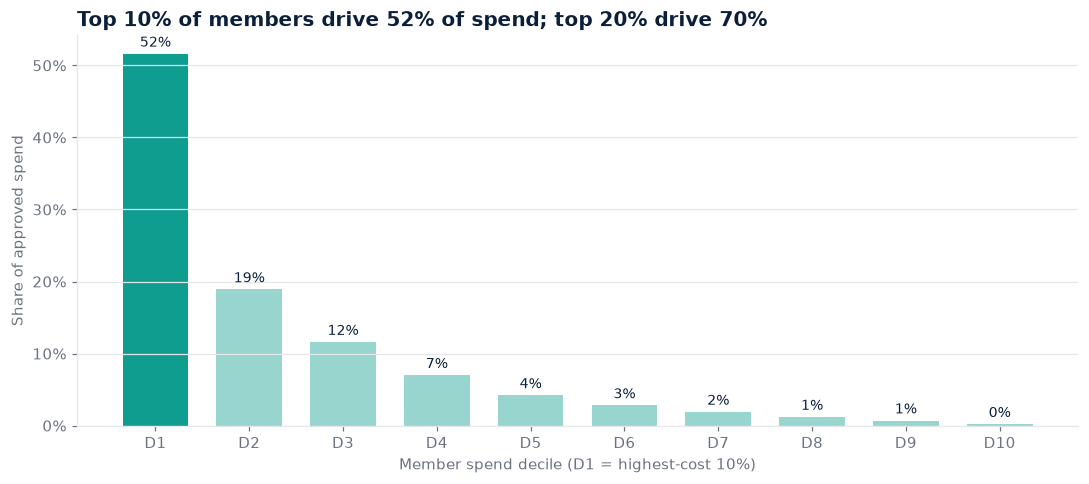

In [18]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(q08.decile, q08.pct_of_spend, color=[TEAL if d == 1 else "#99D5CF" for d in q08.decile], width=0.7)
for x, v, c in zip(q08.decile, q08.pct_of_spend, q08.cumulative_pct_of_spend):
    ax.text(x, v + 1, f"{v:.0f}%", ha="center", fontsize=9, color=NAVY)
ax.set_xticks(q08.decile, [f"D{d}" for d in q08.decile])
ax.yaxis.set_major_formatter(mtick.PercentFormatter()); ax.grid(axis="x", visible=False)
ax.set_xlabel("Member spend decile (D1 = highest-cost 10%)"); ax.set_ylabel("Share of approved spend")
ax.set_title(f"Top 10% of members drive {q08.pct_of_spend.iloc[0]:.0f}% of spend; top 20% drive {q08.cumulative_pct_of_spend.iloc[1]:.0f}%")
save(fig, "q08_cost_concentration")

## Q12. Month-over-month cost trend and PMPM
Member-months come from a recursive month calendar joined to policy coverage windows. `LAG(1)` = MoM, `LAG(12)` = YoY PMPM trend.
Service months after Oct 2025 are excluded to allow claims run-out.

In [19]:
q12 = run_sql("12_mom_cost_trends")
q12

,month,claims,billed,approved,member_months,approved_pmpm,mom_change_pct,yoy_pmpm_change_pct,rolling_3m_approved
0,2024-01,9569,5640522.0,2328882.0,9582,243.05,NaN,NaN,2328882.0
1,2024-02,8723,4653046.0,2057060.0,9607,214.12,-11.7,NaN,2192971.0
2,2024-03,8224,4292877.0,1974147.0,9631,204.98,-4.0,NaN,2120029.0
3,2024-04,7689,4325759.0,1888191.0,9658,195.51,-4.4,NaN,1973132.0
4,2024-05,7945,4643957.0,2132827.0,9681,220.31,13.0,NaN,1998388.0
5,2024-06,7218,4110402.0,1890059.0,9711,194.63,-11.4,NaN,1970359.0
6,2024-07,7361,4589859.0,2051562.0,9734,210.76,8.5,NaN,2024816.0
7,2024-08,7794,4408232.0,1963554.0,9758,201.23,-4.3,NaN,1968392.0
8,2024-09,8022,4619185.0,2007099.0,9786,205.10,2.2,NaN,2007405.0
9,2024-10,9072,5072345.0,2285119.0,9807,233.01,13.9,NaN,2085257.0


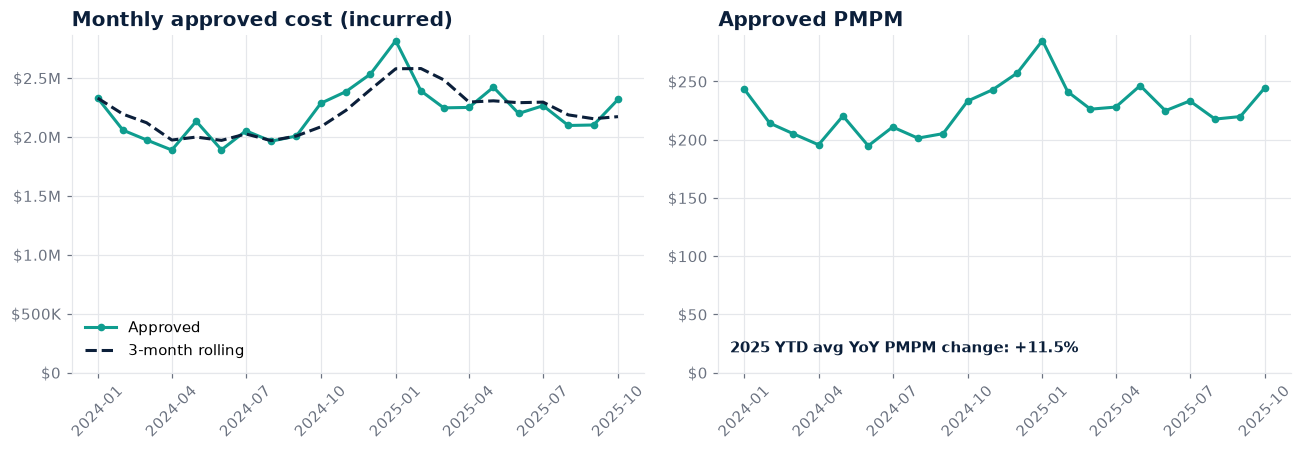

In [20]:
m = pd.to_datetime(q12.month)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.2))
a1.plot(m, q12.approved, color=TEAL, lw=2, marker="o", ms=4, label="Approved")
a1.plot(m, q12.rolling_3m_approved, color=NAVY, lw=2, ls="--", label="3-month rolling")
a1.yaxis.set_major_formatter(money); a1.set_ylim(0, None); a1.legend(loc="lower left")
a1.set_title("Monthly approved cost (incurred)")
a2.plot(m, q12.approved_pmpm, color=TEAL, lw=2, marker="o", ms=4)
a2.set_title("Approved PMPM"); a2.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}")); a2.set_ylim(0, None)
yoy = q12.yoy_pmpm_change_pct.dropna()
a2.text(0.02, 0.06, f"2025 YTD avg YoY PMPM change: {yoy.mean():+.1f}%", transform=a2.transAxes, color=NAVY, fontweight="bold")
for a in (a1, a2):
    a.tick_params(axis="x", rotation=45)
save(fig, "q12_cost_trend")

---
# Part 3 — Claims integrity (fraud, waste & abuse signals)

## Q09. Duplicate claims
Window functions over the key *(member, provider, service date, procedure)* mark every resubmission after the first.

In [21]:
q09 = run_sql("09_duplicate_claims")
q09

,dup_type,duplicate_claims,caught_by_edits,paid_duplicates,pending_duplicates,leakage_rate_pct,dollars_paid_on_duplicates,providers_involved
0,Exact duplicate,2590,2238,296,5,11.4,100945.0,755
1,Near duplicate,1206,668,453,4,37.6,116465.0,528
2,Same-day repeat service,285,3,241,6,84.6,39702.0,212


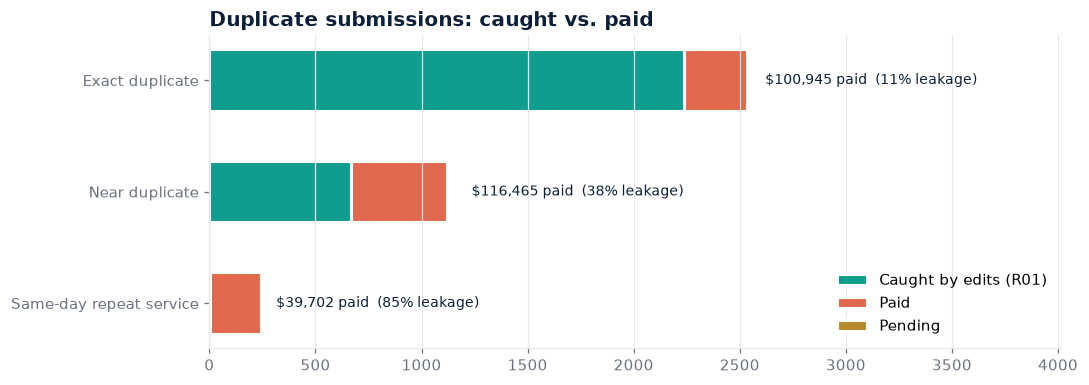

In [22]:
d = q09.set_index("dup_type")
fig, ax = plt.subplots(figsize=(10, 3.6))
left = 0
for col, color, label in [("caught_by_edits", TEAL, "Caught by edits (R01)"), ("paid_duplicates", CORAL, "Paid"),
                          ("pending_duplicates", GOLD, "Pending")]:
    ax.barh(d.index, d[col], left=left, color=color, label=label, height=0.55, edgecolor="white", linewidth=2)
    left = left + d[col]
for y, (lab, row) in enumerate(d.iterrows()):
    ax.text(row.duplicate_claims + 30, y, f"${row.dollars_paid_on_duplicates:,.0f} paid  ({row.leakage_rate_pct:.0f}% leakage)",
            va="center", fontsize=9, color=NAVY)
ax.invert_yaxis(); ax.grid(axis="y", visible=False); ax.set_xlim(0, d.duplicate_claims.max() * 1.55)
ax.legend(loc="lower right"); ax.set_title("Duplicate submissions: caught vs. paid")
save(fig, "q09_duplicates")

**Read:** exact duplicates are mostly stopped by front-end edits, but **near-duplicates** (billed amount nudged by 1–3%)
leak at ~3x the rate. Adding a tolerance band to the duplicate edit is a quick, recoverable win.
*Same-day repeat services* are usually legitimate (e.g. two injections) and belong in a post-pay review queue, not an auto-deny rule.

## Q10. Billed-amount outliers
|z| > 3 within procedure code **and** ≥3x the procedure median. The z-test is written as `(x-μ)² > 9σ²` so it runs on SQLite builds without `SQRT`.

In [23]:
q10 = run_sql("10_billed_amount_outliers")
print(f"{len(q10):,} outlier claims | billed ${q10.billed_amount.sum():,.0f} | "
      f"approved ${q10.approved_amount.fillna(0).sum():,.0f} | status mix: {q10.claim_status.value_counts().to_dict()}")
q10.head(12)

985 outlier claims | billed $6,739,941 | approved $110,509 | status mix: {'Rejected': 516, 'Approved': 415, 'Pending': 54}


,claim_id,procedure_code,procedure_description,provider_id,provider_name,specialty,service_date,procedure_median_billed,billed_amount,times_median,claim_status,rejection_reason_code,approved_amount
0,CLM10193775,92928,Percutaneous coronary stent placement,PR21050,Dr. Nancy Wilson,Cardiology,2025-12-02,21550.10,503836.40,23.4,Pending,NaN,NaN
1,CLM10000192,27759,Open treatment of tibial shaft fracture,PR20974,Valley Orthopedics Associates,Orthopedics,2024-01-03,8206.43,259841.47,31.7,Rejected,R10,0.00
2,CLM10035916,27759,Open treatment of tibial shaft fracture,PR20062,Riverside Orthopedics Associates,Orthopedics,2024-04-26,8206.43,245008.42,29.9,Rejected,R06,0.00
3,CLM10001704,27759,Open treatment of tibial shaft fracture,PR21078,Horizon Orthopedics Associates,Orthopedics,2024-01-04,8206.43,170985.98,20.8,Rejected,R10,0.00
4,CLM10099930,92928,Percutaneous coronary stent placement,PR21142,Dr. Nancy Singh,Cardiology,2025-01-08,21550.10,172605.71,8.0,Approved,NaN,12145.03
5,CLM10149109,27759,Open treatment of tibial shaft fracture,PR21052,Northgate Orthopedics Associates,Orthopedics,2025-06-24,8206.43,142256.34,17.3,Rejected,R10,0.00
6,CLM10006659,27759,Open treatment of tibial shaft fracture,PR21078,Horizon Orthopedics Associates,Orthopedics,2024-01-31,8206.43,131339.27,16.0,Rejected,R05,0.00
7,CLM10083867,47562,Laparoscopic cholecystectomy,PR20107,Summit General Surgery Associates,General Surgery,2024-11-19,8887.00,124064.23,14.0,Rejected,R10,0.00
8,CLM10023686,47562,Laparoscopic cholecystectomy,PR20443,Dr. Wei Khan,General Surgery,2024-03-24,8887.00,119468.05,13.4,Rejected,R10,0.00
9,CLM10117966,27759,Open treatment of tibial shaft fracture,PR20184,Dr. Mark Miller,Orthopedics,2025-02-15,8206.43,99966.20,12.2,Rejected,R10,0.00


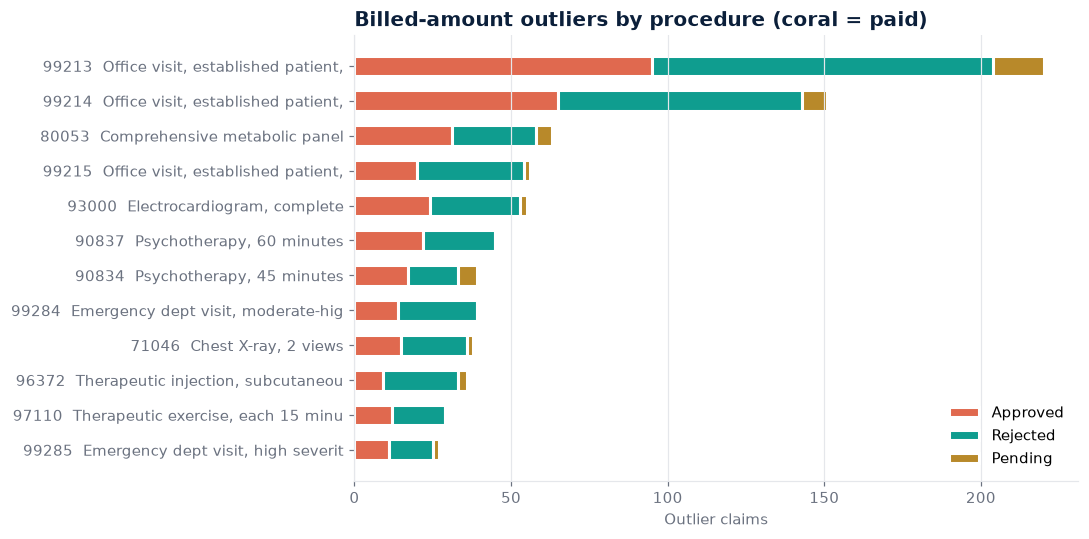

In [24]:
by = (q10.groupby(["procedure_code", "claim_status"]).size().unstack(fill_value=0)
          .assign(total=lambda x: x.sum(axis=1)).sort_values("total").tail(12))
lbl = [f"{c}  {q10.loc[q10.procedure_code == c, 'procedure_description'].iloc[0][:34]}" for c in by.index]
fig, ax = plt.subplots(figsize=(10, 5))
left = 0
for status, color in [("Approved", CORAL), ("Rejected", TEAL), ("Pending", GOLD)]:
    if status in by:
        ax.barh(lbl, by[status], left=left, color=color, label=status, height=0.6, edgecolor="white", linewidth=2)
        left = left + by[status]
ax.grid(axis="y", visible=False); ax.legend(loc="lower right")
ax.set_title("Billed-amount outliers by procedure (coral = paid)")
ax.set_xlabel("Outlier claims")
save(fig, "q10_outliers")

## Q11. Provider fraud-signal scorecard
Five signals, each converted to a within-specialty `PERCENT_RANK()` and blended into a 0–100 score. `red_flags` counts signals at or above the 95th peer percentile.

In [25]:
q11 = run_sql("11_provider_fraud_risk_score")
q11.head(15)

,provider_id,provider_name,specialty,network_status,claims,members,markup_ratio,pct_99215,dup_rate_pct,outlier_rate_pct,claims_per_member,approved_paid,risk_score,red_flags
0,PR20590,Horizon Cardiology Associates,Cardiology,In-Network,146,47,3.20,69.6,12.33,4.79,3.11,69052.0,98.7,4
1,PR20672,Oakwood Endocrinology Associates,Endocrinology,In-Network,627,266,4.37,54.9,11.32,3.35,2.36,87798.0,97.8,4
2,PR21050,Dr. Nancy Wilson,Cardiology,In-Network,901,340,4.72,60.5,9.43,2.66,2.65,441292.0,97.4,3
3,PR20882,Unity Behavioral Health Associates,Behavioral Health,In-Network,541,158,5.35,68.4,9.98,2.96,3.42,72586.0,96.0,4
4,PR20062,Riverside Orthopedics Associates,Orthopedics,In-Network,132,71,5.04,54.2,9.85,2.27,1.86,176433.0,95.8,4
5,PR20903,Valley Internal Medicine Associates,Internal Medicine,Out-of-Network,567,218,5.40,61.6,10.41,3.35,2.60,31309.0,95.1,4
6,PR20327,Horizon Internal Medicine Associates,Internal Medicine,In-Network,387,141,4.31,61.5,9.56,2.84,2.74,44956.0,95.0,4
7,PR20286,Dr. Barbara Young,Family Medicine,In-Network,661,257,4.84,66.5,9.53,2.27,2.57,78451.0,94.1,4
8,PR20798,Crescent Family Medicine Associates,Family Medicine,Out-of-Network,281,112,4.69,60.5,12.46,3.56,2.51,12749.0,93.5,4
9,PR20504,Dr. Elizabeth Thomas,Family Medicine,In-Network,113,42,4.29,65.6,8.85,1.77,2.69,12963.0,93.0,3


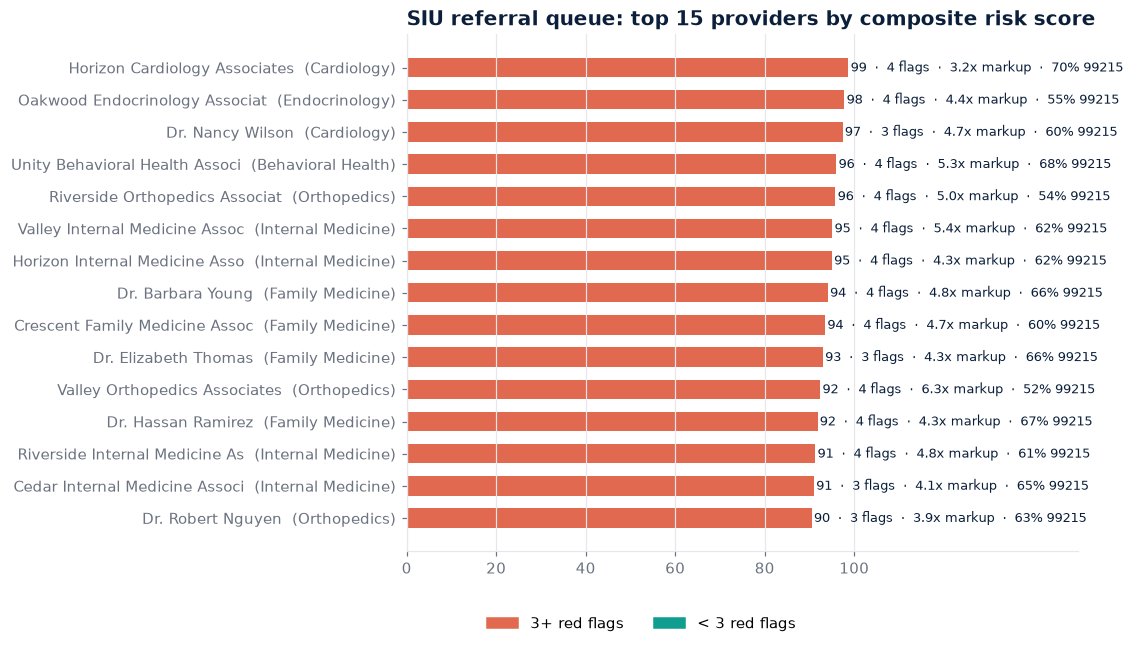

In [26]:
d = q11.head(15).iloc[::-1]
lab = d.provider_name.str.slice(0, 30) + "  (" + d.specialty + ")"
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(lab, d.risk_score, color=[CORAL if f >= 3 else TEAL for f in d.red_flags], height=0.6)
for y, (s, f, mk, up) in enumerate(zip(d.risk_score, d.red_flags, d.markup_ratio, d.pct_99215)):
    ax.text(s + 0.5, y, f"{s:.0f}  ·  {f} flags  ·  {mk:.1f}x markup  ·  {up:.0f}% 99215", va="center", fontsize=8.5, color=NAVY)
ax.set_xlim(0, 150); ax.set_xticks(range(0, 101, 20)); ax.grid(axis="y", visible=False)
ax.legend(handles=[Patch(color=CORAL, label="3+ red flags"), Patch(color=TEAL, label="< 3 red flags")],
          loc="upper center", bbox_to_anchor=(0.35, -0.1), ncol=2)
ax.set_title("SIU referral queue: top 15 providers by composite risk score")
save(fig, "q11_provider_risk")

In [27]:
# How well does the score separate the pack? Compare the flagged cohort with everyone else.
peer = pd.read_sql("""
    SELECT ROUND(SUM(c.billed_amount) / SUM(pc.reference_allowed_amount * c.units), 2) AS markup_ratio,
           ROUND(100.0 * SUM(c.procedure_code = '99215') / SUM(c.procedure_code IN ('99213','99214','99215')), 1) AS pct_99215
    FROM claims c JOIN procedure_codes pc ON pc.procedure_code = c.procedure_code""", con)
flagged = q11[q11.red_flags >= 3]
print(f"{len(flagged)} providers with 3+ red flags | avg markup {flagged.markup_ratio.mean():.2f}x vs book {peer.markup_ratio[0]:.2f}x | "
      f"99215 share {flagged.pct_99215.mean():.0f}% vs book {peer.pct_99215[0]:.0f}% | approved paid ${flagged.approved_paid.sum():,.0f}")

20 providers with 3+ red flags | avg markup 4.44x vs book 1.95x | 99215 share 58% vs book 5% | approved paid $1,629,028


---
## Summary

| Lens | Finding | Action |
|---|---|---|
| Efficiency | Most denials are *avoidable* (network, coding, missing info, duplicates) | Front-end claim scrubbing, directory accuracy, provider education by specialty |
| Efficiency | Manual-review claims take ~4-5x longer than auto-adjudicated | Expand auto-adjudication rules; gold-carding for prior-auth |
| Cost | Top 10% of members ≈ half of spend; high-cost members are multi-morbid | Case & disease management targeting; stop-loss review |
| Cost | Double-digit YoY PMPM trend, winter respiratory peaks | Trend monitoring, site-of-care and unit-cost initiatives |
| Integrity | Near-duplicates leak ~3x more than exact duplicates | Add ±5% tolerance to duplicate edit; recover paid dollars |
| Integrity | A small provider cohort combines extreme markups, upcoding and duplicates | Refer to SIU; pre-payment review |

See the project README for the full write-up.

In [28]:
con.close()